# 06d — Deep Learning: TCN Forecaster (Temporal Convolutional Network)
**Objetivo:** Predecir consumo energético 24 horas adelante usando TCN con ventana deslizante.  
**Diferencia vs LSTM:** Usa convoluciones dilatadas en paralelo en vez de recurrencia secuencial.  
**seq_len:** 48 horas (mejor tradeoff error/tiempo según experimentos LSTM).  
**Comparación:** TCN vs LSTM-Seq vs LSTM-Tabular vs MLP.

## 0. Imports y configuración

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from pathlib import Path
import sys

sys.path.append('../src')

from modeling.DL_TCN import (
    set_seed,
    build_model,
    get_dataloaders,
    train_model,
    evaluate_model,
    save_model,
    load_model,
    DEVICE
)
from utils.metrics import calculate_metrics, print_metrics

print(f"PyTorch version : {torch.__version__}")
print(f"Device          : {DEVICE}")

fh         = 24
SEQ_LEN    = 48     # 2 días — mejor tradeoff según experimentos LSTM
TARGET_COL = 'PJME_MW'

Path('../reports/figures').mkdir(parents=True, exist_ok=True)

PyTorch version : 2.10.0+cu128
Device          : cuda


## 1. Cargar datos

In [2]:
data_dir = Path('../data/processed')

train_df = pd.read_csv(data_dir / f'train_{fh}hr.csv', index_col='Datetime', parse_dates=True)
val_df   = pd.read_csv(data_dir / f'val_{fh}hr.csv',   index_col='Datetime', parse_dates=True)
test_df  = pd.read_csv(data_dir / f'test_{fh}hr.csv',  index_col='Datetime', parse_dates=True)

train_df = train_df.asfreq('h')
val_df   = val_df.asfreq('h')
test_df  = test_df.asfreq('h')

print(f"Train : {train_df.shape}  {train_df.index[0].date()} → {train_df.index[-1].date()}")
print(f"Val   : {val_df.shape}    {val_df.index[0].date()} → {val_df.index[-1].date()}")
print(f"Test  : {test_df.shape}   {test_df.index[0].date()} → {test_df.index[-1].date()}")

Train : (101622, 50)  2002-01-09 → 2013-08-13
Val   : (21752, 50)    2013-08-14 → 2016-02-06
Test  : (21753, 50)   2016-02-07 → 2018-08-02


## 2. DataLoaders + Scaler

In [3]:
train_loader, val_loader, test_loader, scaler_y_mean, scaler_y_std, feature_cols = get_dataloaders(
    train_df, val_df, test_df,
    target_col = TARGET_COL,
    seq_len    = SEQ_LEN,
    batch_size = 64,
)

# Verificar shape — debe ser (batch, seq_len=48, n_features)
sample_X, sample_y = next(iter(train_loader))
print(f"\nX shape : {sample_X.shape}  → (batch, seq_len, features)")
print(f"y shape : {sample_y.shape}  → (batch, 1)")
print(f"\nscaler_y_mean : {scaler_y_mean:.2f} MW")
print(f"scaler_y_std  : {scaler_y_std:.2f} MW")

seq_len         : 48 horas
n_features      : 50
Samples train   : 101574 | val: 21704 | test: 21705
X shape ejemplo : torch.Size([48, 50])  → (seq_len, n_features)

X shape : torch.Size([64, 48, 50])  → (batch, seq_len, features)
y shape : torch.Size([64, 1])  → (batch, 1)

scaler_y_mean : 32411.87 MW
scaler_y_std  : 6502.00 MW


## 3. Construir modelo

In [4]:
set_seed(22)

model = build_model(
    train_loader,
    n_filters   = 64,
    kernel_size = 3,
    n_blocks    = 5,
    dropout     = 0.2,
)

Semilla fijada: 22


c:\ZZZ\Laburos\Portafolio\energy-forecasting-ml\venv\Lib\site-packages\torch\nn\utils\weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


Arquitectura     : TCN(features=50, filters=64, kernel=3, blocks=5)
Ventana receptiva: 124 pasos  (seq_len=48)
Parámetros       : 124,801
Device           : cuda
Ventana receptiva cubre toda la secuencia


## 4. Entrenamiento

In [ ]:
history = train_model(
    model,
    train_loader,
    val_loader,
    epochs    = 50,
    lr        = 1e-3,
    patience  = 10,
    save_path = f'../models/dl_best_tcn.pt',
)

# 17min gpu

Epoch   1/50 | Train: 0.0277 | Val: 0.0070 | Best: 0.0070 | LR: 1.00e-03
Epoch  10/50 | Train: 0.0021 | Val: 0.0022 | Best: 0.0019 | LR: 1.00e-03
Epoch  20/50 | Train: 0.0016 | Val: 0.0014 | Best: 0.0014 | LR: 1.00e-03
Epoch  30/50 | Train: 0.0012 | Val: 0.0011 | Best: 0.0011 | LR: 5.00e-04
Epoch  40/50 | Train: 0.0010 | Val: 0.0011 | Best: 0.0011 | LR: 2.50e-04
Epoch  50/50 | Train: 0.0009 | Val: 0.0010 | Best: 0.0010 | LR: 1.25e-04

Mejor Val Loss: 0.0010 → guardado en ../models/dl_best_tcn_24.pt


In [ ]:
# # Cargar modelo guardado — comentar bloque anterior si se usa esto
# model, scaler_y_mean, scaler_y_std, feature_cols, history = load_model(path=f'../models/dl_tcn.pt')

### Curva de entrenamiento

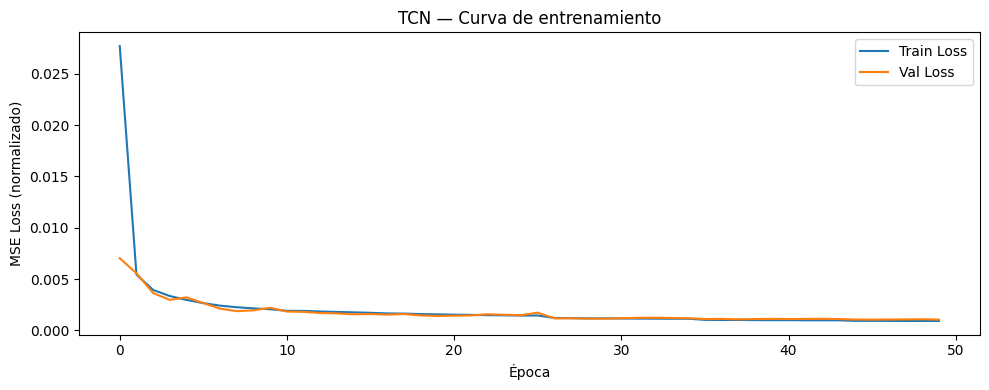

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history['train_loss'], label='Train Loss')
ax.plot(history['val_loss'],   label='Val Loss')
ax.set_xlabel('Época')
ax.set_ylabel('MSE Loss (normalizado)')
ax.set_title('TCN — Curva de entrenamiento')
ax.legend()
plt.tight_layout()
plt.savefig(f'../reports/figures/dl_tcn_training_curve.png', dpi=150)
plt.show()

## 5. Evaluación

In [ ]:
model.load_state_dict(torch.load(f'../models/dl_best_tcn.pt', map_location=DEVICE))

metrics_val,  y_true_val,  y_pred_val  = evaluate_model(model, val_loader,  scaler_y_mean, scaler_y_std, set_name='Val')
metrics_test, y_true_test, y_pred_test = evaluate_model(model, test_loader, scaler_y_mean, scaler_y_std, set_name='Test')


Métricas - Val
Mean_True:  31,500.00 MW
Std_True: 6,186.30 MW
MAE:  149.10 MW
RMSE: 210.32 MW
MAPE: 0.46%
R²:   0.9988


Métricas - Test
Mean_True:  31,095.34 MW
Std_True: 6,450.06 MW
MAE:  163.55 MW
RMSE: 228.01 MW
MAPE: 0.52%
R²:   0.9988



### Predicciones vs Real

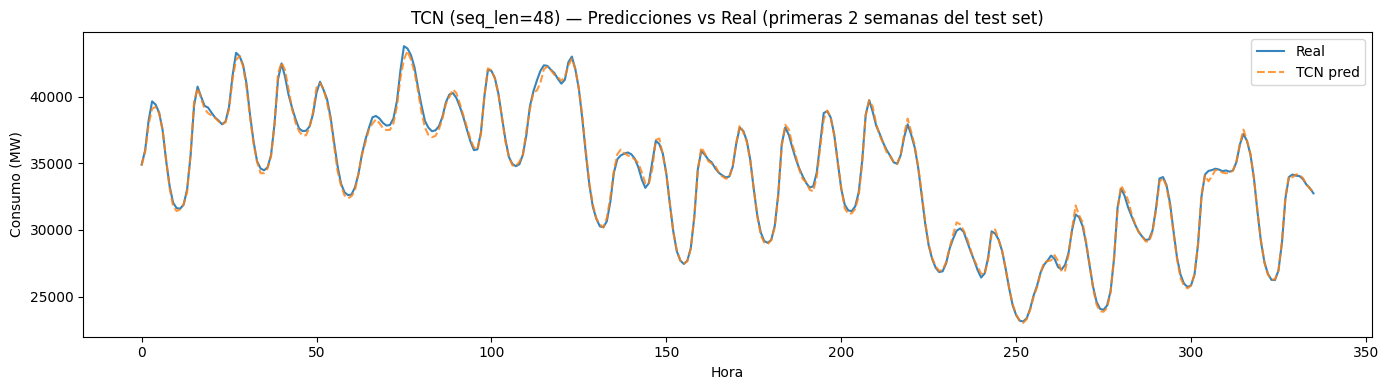

In [ ]:
N = 24 * 14  # 2 semanas

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(y_true_test[:N], label='Real',      alpha=0.9)
ax.plot(y_pred_test[:N], label='TCN pred',  alpha=0.8, linestyle='--')
ax.set_xlabel('Hora')
ax.set_ylabel('Consumo (MW)')
ax.set_title(f'TCN (seq_len={SEQ_LEN}) — Predicciones vs Real (primeras 2 semanas del test set)')
ax.legend()
plt.tight_layout()
plt.savefig(f'../reports/figures/dl_tcn_predictions.png', dpi=150)
plt.show()

### Comparativa rápida vs LSTM Seq

In [10]:
# Cargar métricas LSTM seq para comparar directamente
lstm_metrics = pd.read_csv(f'../reports/metrics/dl_lstm_seq_metrics_48.csv')
tcn_metrics  = pd.DataFrame([metrics_test])
tcn_metrics['model'] = 'TCN'

comparison = pd.concat([lstm_metrics, tcn_metrics], ignore_index=True)
comparison = comparison[['model', 'MAE', 'RMSE', 'MAPE', 'R2']]
print(comparison.to_string(index=False))

   model        MAE       RMSE     MAPE       R2
LSTM_Seq 172.901252 235.056291 0.555928 0.998672
     TCN 163.554293 228.005334 0.517400 0.998750


## 6. Guardar modelo y resultados

In [ ]:
save_model(
    model, scaler_y_mean, scaler_y_std, feature_cols,
    history = history,
    path    = f'../models/dl_tcn.pt'
)

metrics_test['model'] = 'TCN'
results_df = pd.DataFrame([metrics_test])
results_df.to_csv(f'../reports/metrics/dl_tcn_metrics.csv', index=False)
print(results_df.T)

Modelo guardado en ../models/dl_tcn_24.pt
                      0
Mean_True  31095.335546
Std_True    6450.056712
MAE          163.554293
RMSE         228.005334
MAPE             0.5174
R2              0.99875
set                Test
model               TCN
